In [1]:
"""
Marc Karnat
26/07/2021

Romain Karpinski
23/03/2023
"""

'\nMarc Karnat\n26/07/2021\n\nRomain Karpinski\n23/03/2023\n'

In [2]:
import tensorflow.keras as keras
from dare2d.datamodule.generator.regression2d_generator import Regression2dGenerator
from dare2d.datamodule.regression2d import Regression2dDatamodule
from dare2d.model.regression2d_cnn import Regression2dCNN
from dare2d.trainer.basic_trainer import Trainer

2023-04-04 14:54:28.841020: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-04 14:54:28.925027: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-04 14:54:29.350895: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-04-04 14:54:29.350929: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] 

---

* **Global parameters**

---

In [3]:
epochs = 1
steps_per_epoch = 100
target_image_size = 256
target_crop_size = 64
input_channels = 3
batch_size = 16
data_dir = "../data/"

In [4]:
def display(img):
    import matplotlib.pyplot as plt
    import numpy as np
    
    print(np.min(img), np.max(img), img.dtype)
    img = img * 255
    img = img.astype(np.uint8)
    
    plt.imshow(img, cmap="gray")
    plt.show()

---

* **Datamodule**

---


* Create generators and datamodule:



0.0 0.9607843 float32


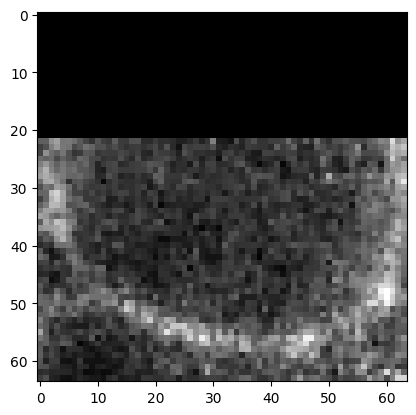

0.0 0.8745098 float32


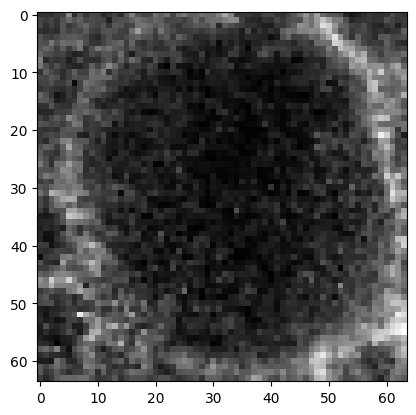

0.0 1.0 float32


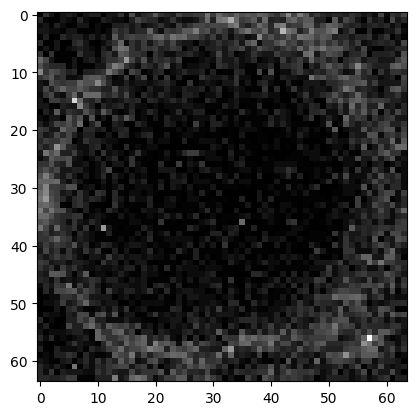

0.0 1.0 float32


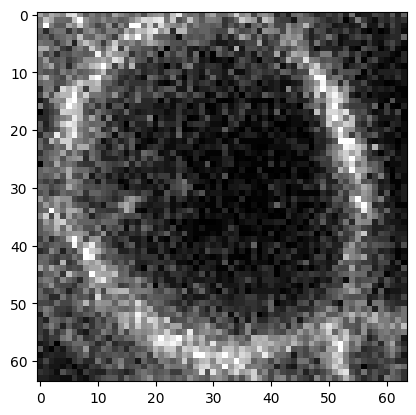

0.0 1.0 float32


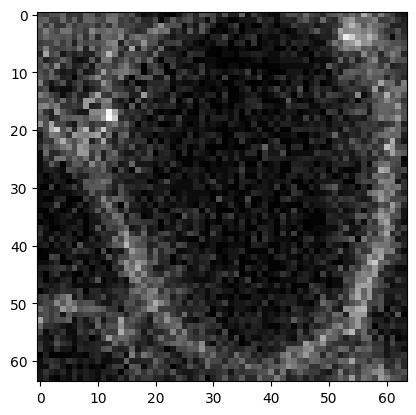

0.0 0.68235296 float32


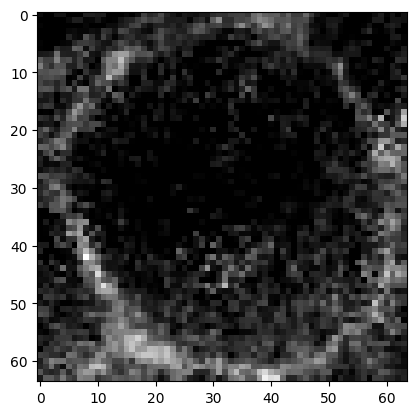

0.0 0.9098039 float32


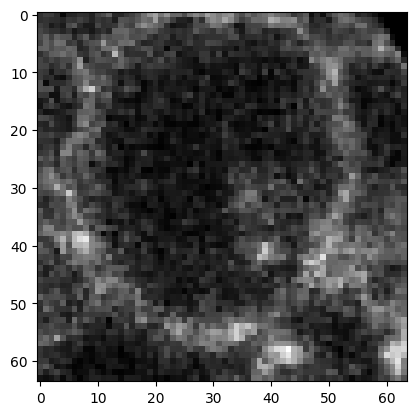

0.0 1.0 float32


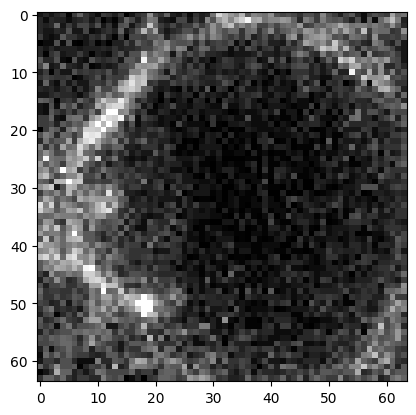

0.0 0.9254902 float32


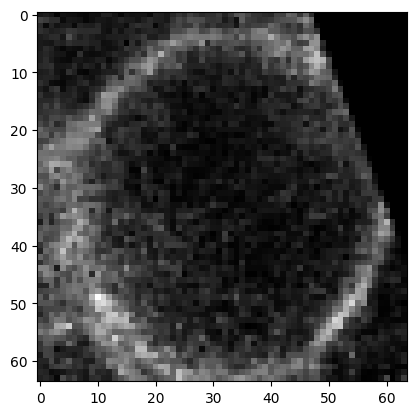

0.0 0.69411767 float32


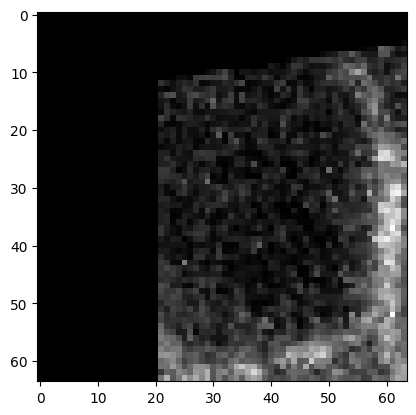

0.003921569 1.0 float32


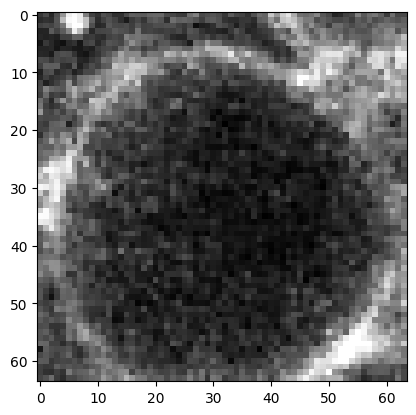

0.03137255 0.4862745 float32


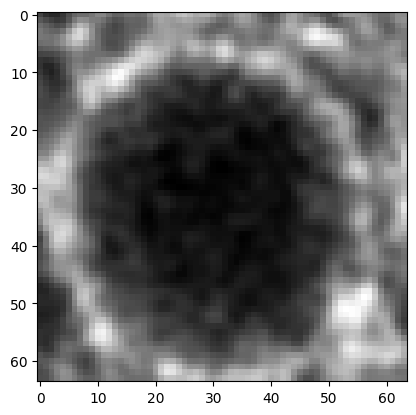

0.0 0.7882353 float32


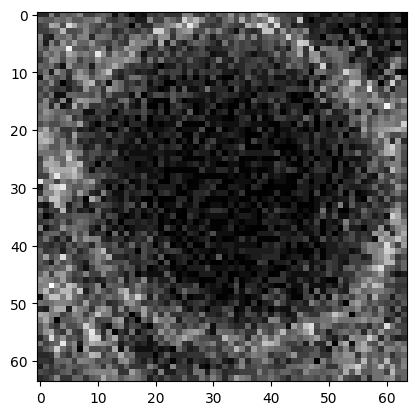

0.0 1.0 float32


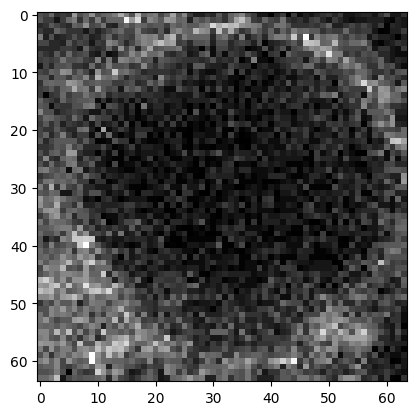

0.0 1.0 float32


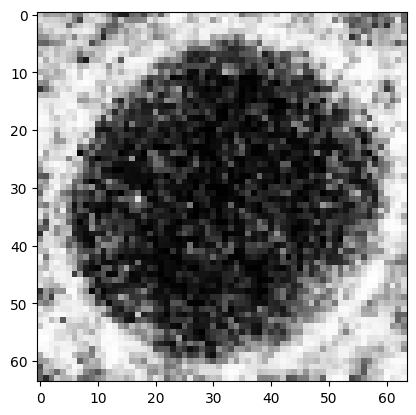

: 

In [13]:
img_dir = "currimg"
previmg_dir = "previmg"
seg_dir = "div_location"
nextimg_dir = "nextimg"

train_generator = Regression2dGenerator(data_dir,
        "train",
        img_dir,
        previmg_dir,
        seg_dir,
        nextimg_dir,
        batch_size,
        target_image_size,
        input_channels,
        n_classes=0,
        crop_size=target_crop_size,
        steps_per_epoch=steps_per_epoch)

val_generator = Regression2dGenerator(data_dir,
        "val",
        img_dir,
        previmg_dir,
        seg_dir,
        nextimg_dir,
        batch_size,
        target_image_size,
        input_channels,
        n_classes=0,
        crop_size=target_crop_size,
        steps_per_epoch=steps_per_epoch)

test_generator = Regression2dGenerator(data_dir,
        "test",
        img_dir,
        previmg_dir,
        seg_dir,
        nextimg_dir,
        batch_size,
        target_image_size,
        input_channels,
        n_classes=0,
        crop_size=target_crop_size,
        steps_per_epoch=steps_per_epoch)

datamodule = Regression2dDatamodule(train_generator, val_generator, test_generator)

x, y = next(train_generator)
for i in range(x.shape[0]):
        display(x[i, :, :, 1])


---


* **Create the model**

---

In [6]:

im_size= target_crop_size
n_channels= input_channels
optimizer = keras.optimizers.experimental.RMSprop(learning_rate=1e-4)
losses = {
    "length_output": keras.losses.MeanSquaredError(),
    "angle_output": keras.losses.MeanSquaredError()
}
n_stages = 2
n_start_filters = 32

model = Regression2dCNN(im_size, n_channels, optimizer, losses, n_stages, n_start_filters)
model.compile()

2023-04-04 14:54:31.768200: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-04 14:54:31.789381: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-04 14:54:31.789569: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-04 14:54:31.790733: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operati

ValueError: Exception encountered when calling layer "conv2d_4" (type Conv2D).

Negative dimension size caused by subtracting 3 from 2 for '{{node conv2d_4/Conv2D}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](Placeholder, conv2d_4/Conv2D/ReadVariableOp)' with input shapes: [?,2,2,128], [3,3,128,256].

Call arguments received by layer "conv2d_4" (type Conv2D):
  • inputs=tf.Tensor(shape=(None, 2, 2, 128), dtype=float32)

---


* **Training**

---

In [ ]:
trainer = Trainer(epochs, steps_per_epoch, resume_from_checkpoint=None, verbose=1)


* Train the model:



In [ ]:
trainer.fit(model_handler=model, datamodule=datamodule, callbacks=None)